# Lalonde CPS Synthetic DGP Application

This notebook uses the Lalonde-Dehejia-Wahba CPS comparison sample to illustrate the tabular simulation DGPs in Trex. It fits synthetic data generators to the observed CPS rows and then compares a simple regression-adjustment ATT estimate on the real and synthetic datasets.

The tensor models are fit locally:

- WGAN-GP, using the optimistic Adam option added for minimax training.
- DDPM-style tabular diffusion.

There is also an optional gpt-oss in-context-learning block. It assumes a local llama.cpp completion endpoint, for example the `gpt-oss` GGUF server in `~/tmp/llama-cpp`. The notebook does not add package dependencies for that path; it uses Python's standard-library HTTP client and skips the block unless the endpoint is running.

In [1]:
from __future__ import annotations

import csv
import json
import subprocess
import time
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from trex import TabularDiffusion, TabularTransformer, TabularWGAN, distribution_metrics

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

SEED = 20260526
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Load and Preprocess the CPS Sample

The notebook expects the numerical replication repository `evanmunro/dswgan-paper` next to Trex as `../dswgan-paper`. If it is missing, the loader clones it.

The Lalonde earnings variables have large dollar magnitudes and heavy right tails. For the generative models, all earnings variables are divided by 1000 before fitting. The regression-adjustment ATT is computed on this scaled data and then reported both in thousands of dollars and in dollars.

In [2]:
LDW_COLUMNS = [
    "t", "age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78",
]
EARNINGS_COLUMNS = ["re74", "re75", "re78"]
BINARY_COLUMNS = ["black", "hispanic", "married", "nodegree"]
NONNEGATIVE_COLUMNS = ["age", "education", "re74", "re75", "re78"]
COVARIATES = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75"]
OUTCOME = "re78"
TREATMENT = "t"

PAPER_REPO = Path("../dswgan-paper")
if not PAPER_REPO.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/evanmunro/dswgan-paper", str(PAPER_REPO)],
        check=True,
    )

DATA_PATH = PAPER_REPO / "data" / "original_data" / "cps_merged.feather"
real_raw = pd.read_feather(DATA_PATH)[LDW_COLUMNS].astype(float)
real = real_raw.copy()
real[EARNINGS_COLUMNS] = real[EARNINGS_COLUMNS] / 1000.0
real.describe().T

,count,mean,std,min,25%,50%,75%,max
t,16177.0,0.011436,0.106329,0.0,0.000000,0.00000,0.00000,1.00000
age,16177.0,33.140508,11.036508,16.0,24.000000,31.00000,42.00000,55.00000
education,16177.0,12.008283,2.868005,0.0,11.000000,12.00000,13.00000,18.00000
black,16177.0,0.082339,0.274889,0.0,0.000000,0.00000,0.00000,1.00000
hispanic,16177.0,0.071892,0.258317,0.0,0.000000,0.00000,0.00000,1.00000
married,16177.0,0.705755,0.455717,0.0,0.000000,1.00000,1.00000,1.00000
nodegree,16177.0,0.300550,0.458511,0.0,0.000000,0.00000,1.00000,1.00000
re74,16177.0,13.880469,9.613115,0.0,4.075275,14.89239,23.49161,35.04007
re75,16177.0,13.512214,9.313207,0.0,4.103419,14.37450,22.83019,25.24355
re78,16177.0,14.749482,9.670996,0.0,5.492710,16.24022,25.56467,60.30793


In [3]:
real[TREATMENT].value_counts().rename("count").to_frame().assign(share=lambda d: d["count"] / len(real))

,count,share
t,,
0.0,15992,0.988564
1.0,185,0.011436


## Regression-Adjustment Estimand

For each dataset, estimate the ATT by fitting the untreated outcome regression

$$
E[Y_i(0) \mid X_i] = X_i'\gamma
$$

on controls and predicting untreated earnings for treated units. Because `re78`, `re75`, and `re74` are measured in thousands of dollars in this notebook, the estimate is naturally in thousands of dollars.

In [4]:
def design_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.column_stack([np.ones(len(df)), df[COVARIATES].to_numpy(dtype=float)])


def regression_adjustment_att(df: pd.DataFrame) -> dict[str, float | int | str]:
    data = df[LDW_COLUMNS].astype(float).copy()
    t = data[TREATMENT].to_numpy(dtype=int)
    y = data[OUTCOME].to_numpy(dtype=float)
    X = design_matrix(data)
    treated = t == 1
    control = t == 0
    if treated.sum() < 5 or control.sum() <= X.shape[1] + 1:
        return {
            "att_ra_thousand": np.nan,
            "att_ra_dollars": np.nan,
            "se_thousand": np.nan,
            "se_dollars": np.nan,
            "n": len(data),
            "n_treated": int(treated.sum()),
            "n_control": int(control.sum()),
            "status": "insufficient treatment or control support",
        }
    beta0 = np.linalg.lstsq(X[control], y[control], rcond=None)[0]
    treated_effects = y[treated] - X[treated] @ beta0
    att = float(treated_effects.mean())
    se = float(treated_effects.std(ddof=1) / np.sqrt(treated.sum()))
    return {
        "att_ra_thousand": att,
        "att_ra_dollars": 1000.0 * att,
        "se_thousand": se,
        "se_dollars": 1000.0 * se,
        "n": len(data),
        "n_treated": int(treated.sum()),
        "n_control": int(control.sum()),
        "status": "ok",
    }


def make_result_row(name: str, df: pd.DataFrame) -> dict[str, float | int | str]:
    row = {"dataset": name}
    row.update(regression_adjustment_att(df))
    return row

make_result_row("real CPS", real)

{'dataset': 'real CPS',
 'att_ra_thousand': 0.6898581362895079,
 'att_ra_dollars': 689.8581362895079,
 'se_thousand': 0.5984572421269193,
 'se_dollars': 598.4572421269193,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok'}

## Conditional Synthetic Generators

Treatment is rare in the CPS sample. Rather than ask an unconditional model to rediscover that small treated mass and then threshold a noisy generated `t`, the generators below condition on treatment status and generate the remaining columns. The synthetic datasets reuse the empirical treatment vector in a random order.

This keeps the application centered on the distribution of covariates and outcomes given treatment status, which is what regression adjustment uses.

In [5]:
OUTPUT_DIR = Path("tmp/lalonde_cps_application")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_columns = [column for column in LDW_COLUMNS if column != TREATMENT]
feature_binary = [column for column in BINARY_COLUMNS if column in feature_columns]
feature_nonnegative = [column for column in NONNEGATIVE_COLUMNS if column in feature_columns]

features = real[feature_columns].copy()
context = real[[TREATMENT]].to_numpy(dtype=np.float32)
context_synth = rng.permutation(context, axis=0)

transformer = TabularTransformer(
    column_names=feature_columns,
    binary_columns=feature_binary,
    nonnegative_columns=feature_nonnegative,
).fit(features)
train_z = transformer.transform(features)
lower, upper = transformer.transformed_bounds()


def rebuild_dataset(generated_features: np.ndarray, generated_t: np.ndarray) -> pd.DataFrame:
    out = pd.DataFrame(generated_features, columns=feature_columns)
    out.insert(0, TREATMENT, generated_t.reshape(-1).astype(float))
    return out[LDW_COLUMNS].astype(float)


def postprocess_synthetic(df: pd.DataFrame) -> pd.DataFrame:
    out = df[LDW_COLUMNS].astype(float).copy()
    for col in [TREATMENT, *BINARY_COLUMNS]:
        out[col] = (np.clip(out[col], 0.0, 1.0) >= 0.5).astype(float)
    for col in NONNEGATIVE_COLUMNS:
        out[col] = np.maximum(out[col], 0.0)
    return out

### WGAN-GP

In [6]:
wgan_start = time.perf_counter()
wgan = TabularWGAN(
    hidden_dims=(64, 64),
    critic_hidden_dims=(64, 64),
    batch_size=512,
    max_steps=800,
    critic_steps=2,
    lr=1e-4,
    optimizer="optimistic_adam",
    gp_weight=5.0,
    binary_dims=transformer.binary_indices,
    lower_bounds=lower,
    upper_bounds=upper,
    seed=SEED,
    device=DEVICE,
)
wgan.fit(train_z, context=context)
wgan_z = wgan.sample(len(real), context=context_synth).numpy()
wgan_features = transformer.inverse_transform(wgan_z, random_state=SEED)
wgan_df = postprocess_synthetic(rebuild_dataset(wgan_features, context_synth))
wgan_seconds = time.perf_counter() - wgan_start
wgan_df.to_csv(OUTPUT_DIR / "cps_wgan_fake.csv", index=False)
make_result_row("WGAN-GP synthetic", wgan_df) | {"seconds": round(wgan_seconds, 2)}

/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'dataset': 'WGAN-GP synthetic',
 'att_ra_thousand': 0.10335446754496672,
 'att_ra_dollars': 103.35446754496671,
 'se_thousand': 0.18057378144864591,
 'se_dollars': 180.57378144864592,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 10.16}

### DDPM-Style Tabular Diffusion

In [7]:
ddpm_start = time.perf_counter()
ddpm = TabularDiffusion(
    hidden_dims=(64, 64),
    n_timesteps=50,
    batch_size=512,
    max_steps=800,
    lr=1e-4,
    seed=SEED,
    device=DEVICE,
)
ddpm.fit(train_z, context=context)
ddpm_z = ddpm.sample(len(real), context=context_synth).numpy()
ddpm_features = transformer.inverse_transform(ddpm_z, random_state=SEED)
ddpm_df = postprocess_synthetic(rebuild_dataset(ddpm_features, context_synth))
ddpm_seconds = time.perf_counter() - ddpm_start
ddpm_df.to_csv(OUTPUT_DIR / "cps_ddpm_fake.csv", index=False)
make_result_row("DDPM synthetic", ddpm_df) | {"seconds": round(ddpm_seconds, 2)}

{'dataset': 'DDPM synthetic',
 'att_ra_thousand': 0.7736336499388825,
 'att_ra_dollars': 773.6336499388825,
 'se_thousand': 0.5609664029386555,
 'se_dollars': 560.9664029386555,
 'n': 16177,
 'n_treated': 185,
 'n_control': 15992,
 'status': 'ok',
 'seconds': 2.25}

### Optional gpt-oss ICL via llama.cpp

This block uses a local llama.cpp completion endpoint. If the gpt-oss server is not running, the notebook records that ICL was skipped. The default ICL sample is intentionally small so the notebook remains executable. It requests treated and control rows separately so regression adjustment has support; increase `ICL_SAMPLE_SIZE` and adjust `ICL_TREATED_COUNT` for a fuller comparison run. A typical server path on this machine is `~/tmp/llama-cpp` with a completion endpoint at `http://127.0.0.1:8080/completion`.

In [8]:
RUN_GPT_OSS_ICL = True
GPT_OSS_COMPLETION_URL = "http://127.0.0.1:8080/completion"
ICL_SAMPLE_SIZE = 128
ICL_TREATED_COUNT = 16
ICL_ROWS_PER_PROMPT = 8
ICL_EXAMPLES = 24
ICL_MAX_ATTEMPTS = 80


def endpoint_available(url: str, timeout: float = 2.0) -> bool:
    health_url = url.rsplit("/", 1)[0] + "/health"
    try:
        with urlopen(health_url, timeout=timeout) as response:
            return response.status < 500
    except Exception:
        return False


def gptoss_prompt(
    training: pd.DataFrame,
    rows_requested: int,
    examples: int,
    seed: int,
    treatment_value: int,
) -> str:
    local_rng = np.random.default_rng(seed)
    subset = training[training[TREATMENT] == float(treatment_value)]
    idx = local_rng.choice(len(subset), min(examples, len(subset)), replace=False)
    header = ",".join(LDW_COLUMNS)
    example_rows = "\n".join(
        ",".join(f"{value:.6g}" for value in subset.iloc[i][LDW_COLUMNS].to_numpy(dtype=float))
        for i in idx
    )
    user_message = (
        f"Return only {rows_requested} numeric CSV rows. No prose. Earnings columns are in thousands of dollars.\n"
        f"Every row must have t={treatment_value}.\n"
        f"Columns: {header}\n"
        "Examples:\n"
        f"{example_rows}\n"
        "CSV:\n"
    )
    return (
        "<|start|>system<|message|>"
        "You are a CSV generator for an econometric dataset. No reasoning. No prose."
        "<|end|><|start|>user<|message|>"
        f"{user_message}"
        "<|end|><|start|>assistant<|channel|>final<|message|>"
    )

def complete_llamacpp(prompt: str, url: str, max_new_tokens: int = 256, timeout: float = 240.0) -> str:
    payload = {
        "prompt": prompt,
        "n_predict": max_new_tokens,
        "temperature": 0.7,
        "stream": False,
        "cache_prompt": False,
        "stop": [],
    }
    request = Request(
        url,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urlopen(request, timeout=timeout) as response:
        body = json.loads(response.read().decode("utf-8"))
    if "content" in body:
        return str(body["content"])
    choices = body.get("choices")
    if isinstance(choices, list) and choices and "text" in choices[0]:
        return str(choices[0]["text"])
    raise RuntimeError(f"Unexpected completion response: {body}")


def parse_csv_rows(text: str) -> list[list[float]]:
    rows = []
    for line in text.splitlines():
        parts = [part.strip() for part in line.split(",")]
        if parts == LDW_COLUMNS or len(parts) != len(LDW_COLUMNS):
            continue
        try:
            rows.append([float(part) for part in parts])
        except ValueError:
            continue
    return rows


def sample_gptoss_group(treatment_value: int, n_rows: int, seed_offset: int) -> pd.DataFrame:
    rows = []
    attempts = 0
    while len(rows) < n_rows and attempts < ICL_MAX_ATTEMPTS:
        attempts += 1
        requested = min(ICL_ROWS_PER_PROMPT, n_rows - len(rows))
        prompt = gptoss_prompt(real, requested, ICL_EXAMPLES, SEED + seed_offset + attempts, treatment_value)
        text = complete_llamacpp(prompt, GPT_OSS_COMPLETION_URL)
        parsed = parse_csv_rows(text)
        for row in parsed:
            row[0] = float(treatment_value)
        rows.extend(parsed)
    if len(rows) < n_rows:
        raise RuntimeError(
            f"Parsed {len(rows)} valid rows with t={treatment_value} after {attempts} attempts."
        )
    return pd.DataFrame(rows[:n_rows], columns=LDW_COLUMNS)


def sample_gptoss_icl() -> pd.DataFrame:
    treated_n = min(ICL_TREATED_COUNT, ICL_SAMPLE_SIZE)
    control_n = ICL_SAMPLE_SIZE - treated_n
    treated = sample_gptoss_group(1, treated_n, 10_000)
    controls = sample_gptoss_group(0, control_n, 20_000)
    df = pd.concat([treated, controls], ignore_index=True)
    df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return postprocess_synthetic(df)



if RUN_GPT_OSS_ICL and endpoint_available(GPT_OSS_COMPLETION_URL):
    icl_start = time.perf_counter()
    gptoss_df = sample_gptoss_icl()
    gptoss_seconds = time.perf_counter() - icl_start
    gptoss_df.to_csv(OUTPUT_DIR / "cps_gptoss_icl_fake.csv", index=False)
    gptoss_status = make_result_row("gpt-oss ICL synthetic", gptoss_df) | {"seconds": round(gptoss_seconds, 2)}
else:
    gptoss_df = None
    gptoss_status = {
        "dataset": "gpt-oss ICL synthetic",
        "att_ra_thousand": np.nan,
        "att_ra_dollars": np.nan,
        "se_thousand": np.nan,
        "se_dollars": np.nan,
        "n": 0,
        "n_treated": 0,
        "n_control": 0,
        "status": "skipped; llama.cpp gpt-oss completion endpoint was not reachable",
        "seconds": 0.0,
    }

gptoss_status

{'dataset': 'gpt-oss ICL synthetic',
 'att_ra_thousand': -2.6692778067809755,
 'att_ra_dollars': -2669.2778067809754,
 'se_thousand': 0.6981532276332251,
 'se_dollars': 698.153227633225,
 'n': 128,
 'n_treated': 16,
 'n_control': 112,
 'status': 'ok',
 'seconds': 114.45}

## ATT Estimates

In [9]:
datasets = {
    "real CPS": real,
    "WGAN-GP synthetic": wgan_df,
    "DDPM synthetic": ddpm_df,
}
if gptoss_df is not None:
    datasets["gpt-oss ICL synthetic"] = gptoss_df

att_table = pd.DataFrame([make_result_row(name, df) for name, df in datasets.items()])
if gptoss_df is None:
    att_table = pd.concat([att_table, pd.DataFrame([gptoss_status])], ignore_index=True)

att_table.to_csv(OUTPUT_DIR / "cps_att_estimates.csv", index=False)
att_table

,dataset,att_ra_thousand,att_ra_dollars,se_thousand,se_dollars,n,n_treated,n_control,status
0,real CPS,0.689858,689.858136,0.598457,598.457242,16177,185,15992,ok
1,WGAN-GP synthetic,0.103354,103.354468,0.180574,180.573781,16177,185,15992,ok
2,DDPM synthetic,0.773634,773.633650,0.560966,560.966403,16177,185,15992,ok
3,gpt-oss ICL synthetic,-2.669278,-2669.277807,0.698153,698.153228,128,16,112,ok


## Distribution Distances

The ATT estimate is only one downstream statistic. The tables below report broad row-distribution distances, including sliced Wasserstein distance and Frobenius differences in covariance and correlation matrices. Metrics are computed on the scaled data used for fitting.

In [10]:
def metric_row(name: str, df: pd.DataFrame) -> dict[str, float | str]:
    metrics = distribution_metrics(real[LDW_COLUMNS].to_numpy(), df[LDW_COLUMNS].to_numpy(), seed=SEED)
    return {"dataset": name, **metrics}

metric_table = pd.DataFrame([
    metric_row("WGAN-GP synthetic", wgan_df),
    metric_row("DDPM synthetic", ddpm_df),
] + ([metric_row("gpt-oss ICL synthetic", gptoss_df)] if gptoss_df is not None else []))
metric_table.to_csv(OUTPUT_DIR / "cps_distribution_metrics.csv", index=False)
metric_table[[
    "dataset",
    "sliced_wasserstein",
    "cov_frobenius",
    "corr_frobenius",
    "marginal_w1_mean",
    "marginal_ks_mean",
    "mean_l2",
]].round(4)

,dataset,sliced_wasserstein,cov_frobenius,corr_frobenius,marginal_w1_mean,marginal_ks_mean,mean_l2
0,WGAN-GP synthetic,1.0665,139.2258,2.9873,0.9503,0.1479,1.6726
1,DDPM synthetic,1.1100,106.8796,1.1815,1.0801,0.0989,1.0364
2,gpt-oss ICL synthetic,12.8546,150.2461,1.9329,1.6737,0.1494,5.7540


## Covariance and Correlation Matrices

In [11]:
matrix_columns = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75", "re78"]

def covariance_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.cov(df[matrix_columns].to_numpy(dtype=float), rowvar=False)

def correlation_matrix(df: pd.DataFrame) -> np.ndarray:
    return np.corrcoef(df[matrix_columns].to_numpy(dtype=float), rowvar=False)


def matrix_distance_table() -> pd.DataFrame:
    real_cov = covariance_matrix(real)
    real_corr = correlation_matrix(real)
    rows = []
    for name, df in datasets.items():
        if name == "real CPS":
            continue
        rows.append({
            "dataset": name,
            "cov_frobenius_manual": np.linalg.norm(covariance_matrix(df) - real_cov, ord="fro"),
            "corr_frobenius_manual": np.linalg.norm(correlation_matrix(df) - real_corr, ord="fro"),
        })
    return pd.DataFrame(rows).round(4)

matrix_distance_table()

/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,dataset,cov_frobenius_manual,corr_frobenius_manual
0,WGAN-GP synthetic,139.2255,NaN
1,DDPM synthetic,106.8791,1.0573
2,gpt-oss ICL synthetic,150.2296,1.6529


/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alal/miniforge3/envs/torch/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


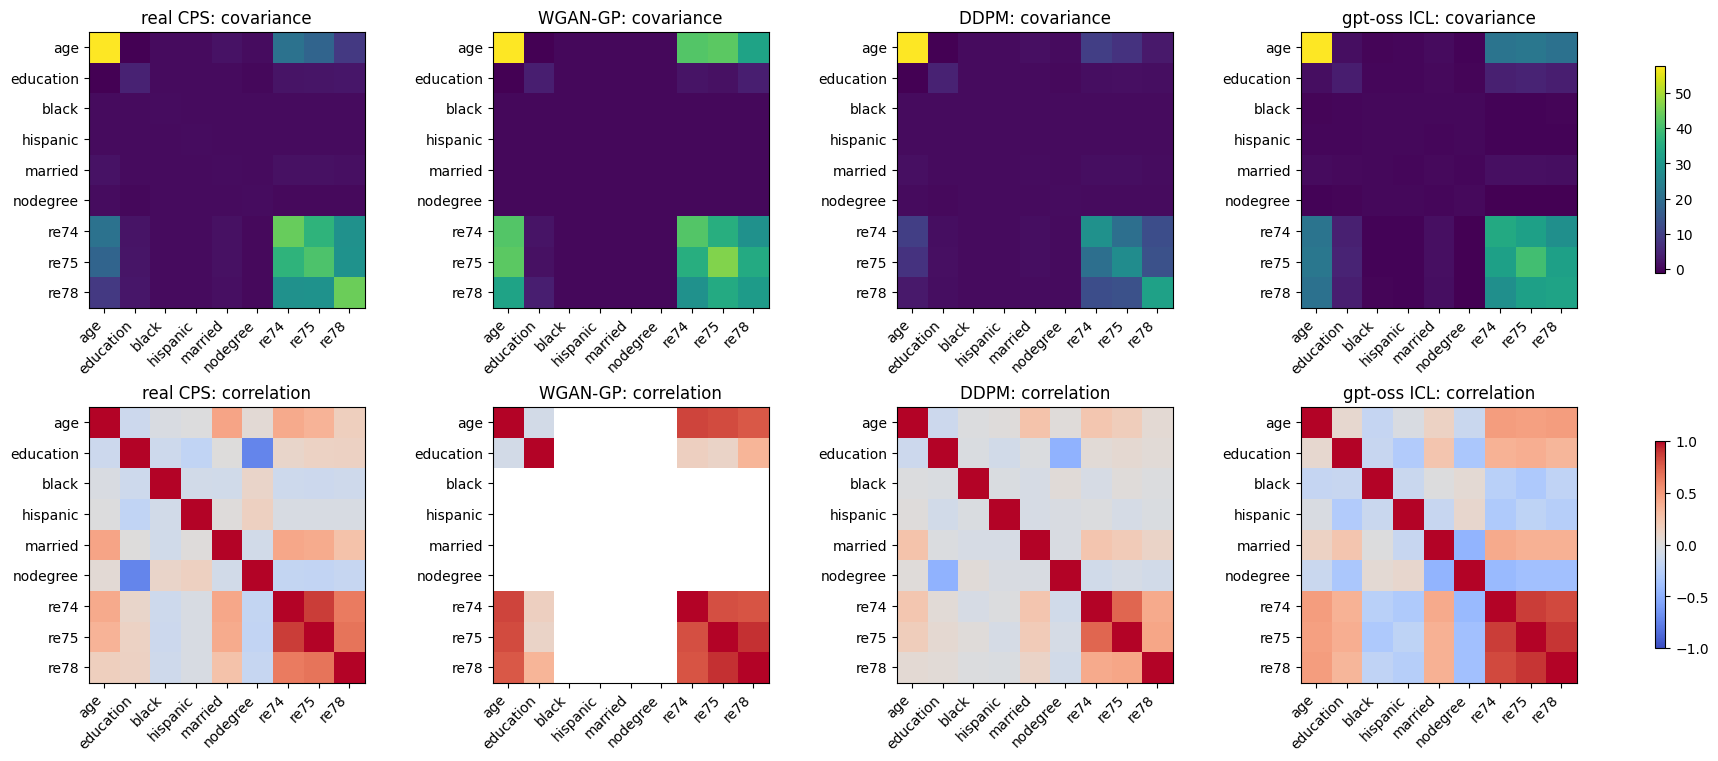

In [12]:
plot_sets = [("real CPS", real), ("WGAN-GP", wgan_df), ("DDPM", ddpm_df)]
if gptoss_df is not None:
    plot_sets.append(("gpt-oss ICL", gptoss_df))

fig, axes = plt.subplots(2, len(plot_sets), figsize=(4.4 * len(plot_sets), 7.5), constrained_layout=True)
if len(plot_sets) == 1:
    axes = np.asarray(axes).reshape(2, 1)

for j, (name, df) in enumerate(plot_sets):
    cov = covariance_matrix(df)
    corr = correlation_matrix(df)
    im0 = axes[0, j].imshow(cov, cmap="viridis")
    axes[0, j].set_title(f"{name}: covariance")
    im1 = axes[1, j].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1, j].set_title(f"{name}: correlation")
    for ax in axes[:, j]:
        ax.set_xticks(range(len(matrix_columns)))
        ax.set_xticklabels(matrix_columns, rotation=45, ha="right")
        ax.set_yticks(range(len(matrix_columns)))
        ax.set_yticklabels(matrix_columns)

fig.colorbar(im0, ax=axes[0, :], shrink=0.75, location="right")
fig.colorbar(im1, ax=axes[1, :], shrink=0.75, location="right")
plt.show()

## Earnings Scatter Check

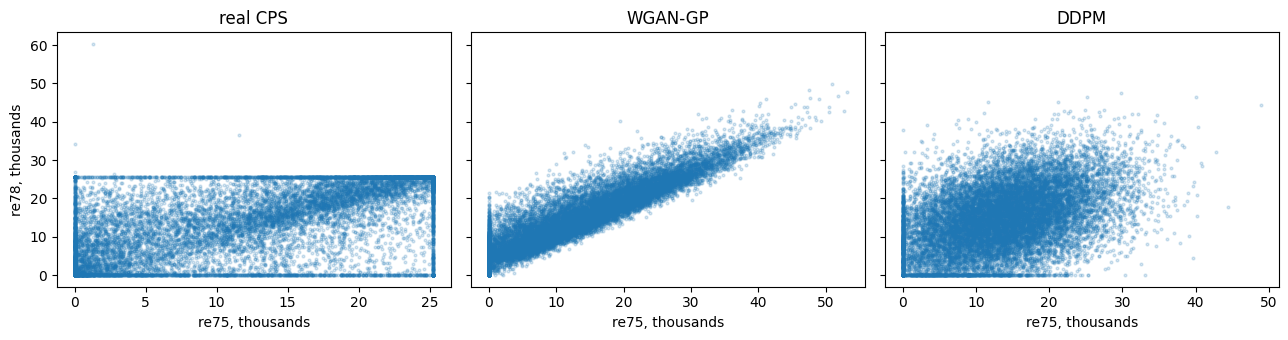

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
plot_items = [("real CPS", real), ("WGAN-GP", wgan_df), ("DDPM", ddpm_df)]
for ax, (title, df) in zip(axes, plot_items):
    ax.scatter(df["re75"], df["re78"], s=4, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("re75, thousands")
axes[0].set_ylabel("re78, thousands")
fig.tight_layout()
plt.show()

## Takeaways

This run is a useful debugging example. Training on raw dollar earnings produced poor synthetic ATT behavior because the earnings columns have large magnitudes and heavy tails. Scaling `re74`, `re75`, and `re78` by 1000 makes the simulation problem much better conditioned.

In the executed run, the DDPM synthetic dataset gives a regression-adjustment ATT close to the real CPS estimate, while the WGAN-GP estimate remains noticeably attenuated. The distribution diagnostics help explain why: DDPM has substantially better covariance and correlation Frobenius distances, even though WGAN is competitive on one aggregate sliced-Wasserstein number. For this application, preserving the joint earnings/covariate covariance structure is directly relevant to regression adjustment.

The gpt-oss ICL block now runs against the local llama.cpp endpoint. The default sample is deliberately small and treatment-conditioned so the notebook remains executable and the RA estimator has support. In this run, however, the generated rows are visibly template-like and the ATT estimate is poor. Treat this as endpoint plumbing and a baseline sanity check, not as evidence that the ICL approach is competitive without a better prompting/sampling design.

The key workflow is:

1. Pull the CPS sample and scale earnings by 1000.
2. Fit treatment-conditional WGAN and DDPM row generators.
3. Optionally sample rows from a local gpt-oss llama.cpp completion endpoint.
4. Run the same regression-adjustment estimator on real and synthetic datasets.
5. Compare distribution distances and covariance/correlation structure.

The optional ICL path is deliberately kept outside the Trex package API. It is useful for one-off research comparison, but it depends on a separately managed local model server rather than a stable package dependency.